# Finite Difference Method for Quantum Mechanics

## Imports


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.sparse.linalg as linalg
from scipy.sparse.linalg import eigsh
import time
import finite_difference_quantum as fin


## Finite Difference Functions


## Timing Comparison: 2nd vs 4th Order Methods


## Convergence Analysis: 4th Order Method


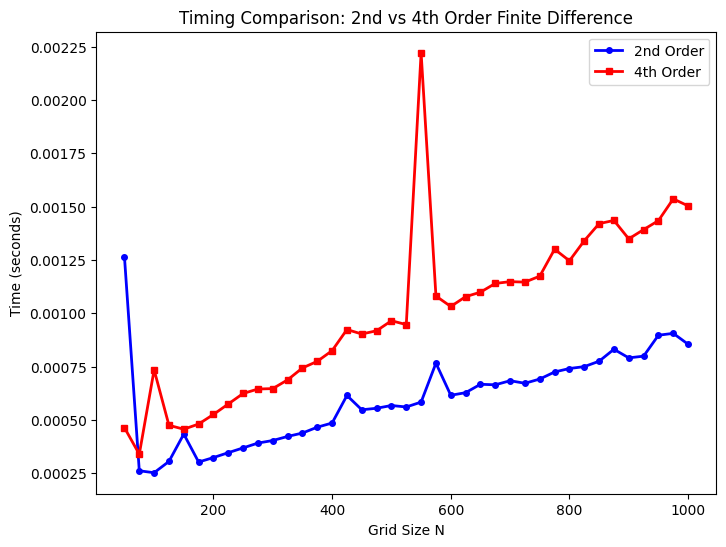

In [26]:
def timing_hamiltonian_2nd(N):
    def V(x): return 0.5 * x**2
    x_left, x_right = -5.0, 5.0
    start = time.time()
    H = fin.hamiltonian(V, x_left, x_right, N)
    end = time.time()
    return end - start

def timing_hamiltonian_4th(N):
    def V(x): return 0.5 * x**2
    x_left, x_right = -5.0, 5.0
    start = time.time()
    H = fin.hamiltonian_4th(V, x_left, x_right, N)
    end = time.time()
    return end - start

N_values = np.arange(50, 1001, 25)
timing_2nd = []
timing_4th = []

for N in N_values:
    timing_2nd.append(timing_hamiltonian_2nd(N))
    timing_4th.append(timing_hamiltonian_4th(N))

plt.figure(figsize=(8, 6))
plt.plot(N_values, timing_2nd, 'b-o', label='2nd Order', linewidth=2, markersize=4)
plt.plot(N_values, timing_4th, 'r-s', label='4th Order', linewidth=2, markersize=4)
plt.xlabel('Grid Size N')
plt.ylabel('Time (seconds)')
plt.title('Timing Comparison: 2nd vs 4th Order Finite Difference')
plt.legend()
plt.show()



## Convergence Analysis: 4th Order Method


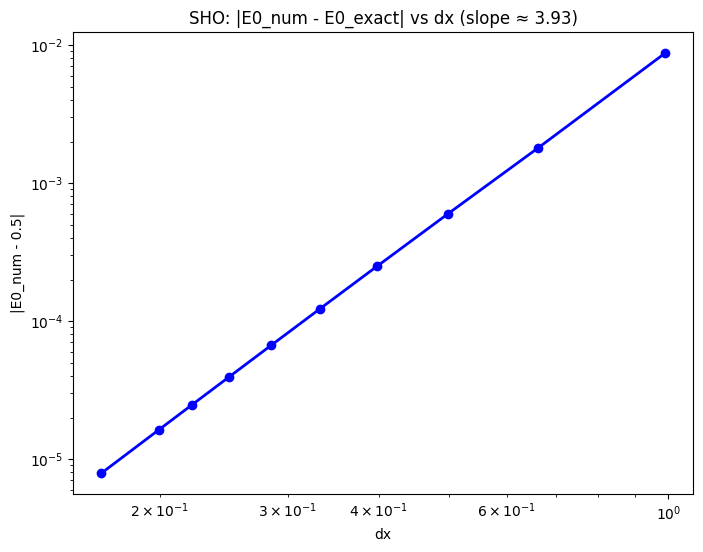

In [27]:
def E_exact_sho(n, omega=1.0): 
    return n + 0.5

target_n = 0
E0_exact = E_exact_sho(target_n)

x_inf = 100.0 
x_left, x_right = -x_inf, x_inf

def V(x): 
    return 0.5 * x**2

N_list = [201, 301, 401, 501, 601, 701, 801, 901, 1001, 1201]
errs, dxs = [], []

for N_test in N_list:
    Ht = fin.hamiltonian_4th(V, x_left, x_right, N_test)
    Et, _ = eigsh(Ht, k=1, which='SM', tol=1e-10, maxiter=2000)
    Et = np.min(Et)
    grid_t = fin.spatial(x_left, x_right, N_test)
    dx = grid_t[1] - grid_t[0]
    error = abs(Et - E0_exact)
    
    dxs.append(dx)
    errs.append(error)

plt.figure(figsize=(8, 6))
plt.loglog(dxs, errs, 'bo-', linewidth=2, markersize=6)

slope = (np.log(errs[-1]) - np.log(errs[0])) / (np.log(dxs[-1]) - np.log(dxs[0]))
plt.title(f"SHO: |E0_num - E0_exact| vs dx (slope ≈ {slope:.2f})")
plt.xlabel("dx")
plt.ylabel("|E0_num - 0.5|")
plt.show()


## Matrix Verification Test


In [28]:
x_left, x_right = 1.0, 2.0
N = 4

def A(x): return 2*x
def B(x): return x**2  
def C(x): return 1.0

grid = fin.spatial(x_left, x_right, N)
print(f"Grid points: {grid}")
print(f"Grid spacing Δ = {grid[1] - grid[0]:.3f}")
print()

a_vals = fin.proj(A, grid)
b_vals = fin.proj(B, grid) 
c_vals = fin.proj(C, grid)

print(f"A(x) values: {a_vals}")
print(f"B(x) values: {b_vals}")
print(f"C(x) values: {c_vals}")
print()


Grid points: [1.2 1.4 1.6 1.8]
Grid spacing Δ = 0.200

A(x) values: [2.4+0.j 2.8+0.j 3.2+0.j 3.6+0.j]
B(x) values: [1.44+0.j 1.96+0.j 2.56+0.j 3.24+0.j]
C(x) values: [1.+0.j 1.+0.j 1.+0.j 1.+0.j]



In [29]:
actual_2nd = fin.sparseMatrixMaker(A, B, C, grid).toarray()
print("Actual 2nd order matrix:")
print(actual_2nd)
print()


Actual 2nd order matrix:
[[  61. +0.j   67.2+0.j    0. +0.j    0. +0.j]
 [-149.8+0.j   71. +0.j   79.8+0.j    0. +0.j]
 [   0. +0.j -172.8+0.j   81. +0.j   92.8+0.j]
 [   0. +0.j    0. +0.j -196.2+0.j   91. +0.j]]



In [30]:
actual_4th = fin.sparse_Matrix_Maker4(A, B, C, grid).toarray()
print("Actual 4th order matrix:")
print(actual_4th)
print()


Actual 4th order matrix:
[[-129.        +0.j   54.8       +0.j   15.6       +0.j   -5.        +0.j]
 [ 110.13333333+0.j -209.        +0.j  123.2       +0.j  -10.85      +0.j]
 [ -14.4       +0.j  124.8       +0.j -239.        +0.j  141.86666667+0.j]
 [  -7.5       +0.j   21.15      +0.j   64.2       +0.j -194.        +0.j]]

